In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import seaborn as sns


In [18]:
df = pd.read_csv("C:/Users/w.i/Downloads/Ai_Project/diabetic_data.csv")


In [19]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [20]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [21]:
df = df.drop(['max_glu_serum', 'A1Cresult'], axis=1)

In [22]:
df.isnull().sum()

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
weight                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose  

In [23]:
for column in df.columns:
    unique_values = df[column].unique()
    print(f"Column '{column}': {unique_values}")

Column 'encounter_id': [  2278392    149190     64410 ... 443854148 443857166 443867222]
Column 'patient_nbr': [  8222157  55629189  86047875 ... 140199494 120975314 175429310]
Column 'race': ['Caucasian' 'AfricanAmerican' '?' 'Other' 'Asian' 'Hispanic']
Column 'gender': ['Female' 'Male' 'Unknown/Invalid']
Column 'age': ['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']
Column 'weight': ['?' '[75-100)' '[50-75)' '[0-25)' '[100-125)' '[25-50)' '[125-150)'
 '[175-200)' '[150-175)' '>200']
Column 'admission_type_id': [6 1 2 3 4 5 8 7]
Column 'discharge_disposition_id': [25  1  3  6  2  5 11  7 10  4 14 18  8 13 12 16 17 22 23  9 20 15 24 28
 19 27]
Column 'admission_source_id': [ 1  7  2  4  5  6 20  3 17  8  9 14 10 22 11 25 13]
Column 'time_in_hospital': [ 1  3  2  4  5 13 12  9  7 10  6 11  8 14]
Column 'payer_code': ['?' 'MC' 'MD' 'HM' 'UN' 'BC' 'SP' 'CP' 'SI' 'DM' 'CM' 'CH' 'PO' 'WC' 'OT'
 'OG' 'MP' 'FR']
Column 'medical_specialty':

In [24]:

mode_race = df['race'].mode()[0]
df['race'] = df['race'].replace('?', mode_race)

In [25]:
mode_gender = df['gender'].mode()[0]
df['gender'] = df['gender'].replace('Unknown/Invalid', mode_gender)

In [26]:
 second_mode = df['medical_specialty'].value_counts().index[1]
 df['medical_specialty'] = df['medical_specialty'].replace('?', second_mode)

In [28]:
 second_modee = df['payer_code'].value_counts().index[1]
 df['payer_code'] = df['payer_code'].replace('?', second_modee)

In [30]:
for column in df.columns:
    unique_values = df[column].unique()
    print(f"Column '{column}': {unique_values}")

Column 'encounter_id': [  2278392    149190     64410 ... 443854148 443857166 443867222]
Column 'patient_nbr': [  8222157  55629189  86047875 ... 140199494 120975314 175429310]
Column 'race': ['Caucasian' 'AfricanAmerican' 'Other' 'Asian' 'Hispanic']
Column 'gender': ['Female' 'Male']
Column 'age': ['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']
Column 'weight': ['?' '[75-100)' '[50-75)' '[0-25)' '[100-125)' '[25-50)' '[125-150)'
 '[175-200)' '[150-175)' '>200']
Column 'admission_type_id': [6 1 2 3 4 5 8 7]
Column 'discharge_disposition_id': [25  1  3  6  2  5 11  7 10  4 14 18  8 13 12 16 17 22 23  9 20 15 24 28
 19 27]
Column 'admission_source_id': [ 1  7  2  4  5  6 20  3 17  8  9 14 10 22 11 25 13]
Column 'time_in_hospital': [ 1  3  2  4  5 13 12  9  7 10  6 11  8 14]
Column 'payer_code': ['MC' 'MD' 'HM' 'UN' 'BC' 'SP' 'CP' 'SI' 'DM' 'CM' 'CH' 'PO' 'WC' 'OT'
 'OG' 'MP' 'FR']
Column 'medical_specialty': ['Pediatrics-Endocrinolog

In [31]:
df = df.drop(['weight'], axis=1)

In [32]:
for column in df.columns:
    unique_values = df[column].unique()
    print(f"Column '{column}': {unique_values}")

Column 'encounter_id': [  2278392    149190     64410 ... 443854148 443857166 443867222]
Column 'patient_nbr': [  8222157  55629189  86047875 ... 140199494 120975314 175429310]
Column 'race': ['Caucasian' 'AfricanAmerican' 'Other' 'Asian' 'Hispanic']
Column 'gender': ['Female' 'Male']
Column 'age': ['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']
Column 'admission_type_id': [6 1 2 3 4 5 8 7]
Column 'discharge_disposition_id': [25  1  3  6  2  5 11  7 10  4 14 18  8 13 12 16 17 22 23  9 20 15 24 28
 19 27]
Column 'admission_source_id': [ 1  7  2  4  5  6 20  3 17  8  9 14 10 22 11 25 13]
Column 'time_in_hospital': [ 1  3  2  4  5 13 12  9  7 10  6 11  8 14]
Column 'payer_code': ['MC' 'MD' 'HM' 'UN' 'BC' 'SP' 'CP' 'SI' 'DM' 'CM' 'CH' 'PO' 'WC' 'OT'
 'OG' 'MP' 'FR']
Column 'medical_specialty': ['Pediatrics-Endocrinology' 'InternalMedicine' 'Family/GeneralPractice'
 'Cardiology' 'Surgery-General' 'Orthopedics' 'Gastroenterology'
 'Surge

In [33]:
for column in ['diag_2', 'diag_3', 'diag_1']:
    mode_val = df[column].mode()[0]
    df[column] = df[column].replace('?',mode_val)

In [34]:
for column in df.columns:
    unique_values = df[column].unique()
    print(f"Column '{column}': {unique_values}")

Column 'encounter_id': [  2278392    149190     64410 ... 443854148 443857166 443867222]
Column 'patient_nbr': [  8222157  55629189  86047875 ... 140199494 120975314 175429310]
Column 'race': ['Caucasian' 'AfricanAmerican' 'Other' 'Asian' 'Hispanic']
Column 'gender': ['Female' 'Male']
Column 'age': ['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']
Column 'admission_type_id': [6 1 2 3 4 5 8 7]
Column 'discharge_disposition_id': [25  1  3  6  2  5 11  7 10  4 14 18  8 13 12 16 17 22 23  9 20 15 24 28
 19 27]
Column 'admission_source_id': [ 1  7  2  4  5  6 20  3 17  8  9 14 10 22 11 25 13]
Column 'time_in_hospital': [ 1  3  2  4  5 13 12  9  7 10  6 11  8 14]
Column 'payer_code': ['MC' 'MD' 'HM' 'UN' 'BC' 'SP' 'CP' 'SI' 'DM' 'CM' 'CH' 'PO' 'WC' 'OT'
 'OG' 'MP' 'FR']
Column 'medical_specialty': ['Pediatrics-Endocrinology' 'InternalMedicine' 'Family/GeneralPractice'
 'Cardiology' 'Surgery-General' 'Orthopedics' 'Gastroenterology'
 'Surge

In [35]:
df = df.drop(['examide', 'citoglipton'],axis=1)


In [36]:
for column in df.columns:
    unique_values = df[column].unique()
    print(f"Column '{column}': {unique_values}")

Column 'encounter_id': [  2278392    149190     64410 ... 443854148 443857166 443867222]
Column 'patient_nbr': [  8222157  55629189  86047875 ... 140199494 120975314 175429310]
Column 'race': ['Caucasian' 'AfricanAmerican' 'Other' 'Asian' 'Hispanic']
Column 'gender': ['Female' 'Male']
Column 'age': ['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']
Column 'admission_type_id': [6 1 2 3 4 5 8 7]
Column 'discharge_disposition_id': [25  1  3  6  2  5 11  7 10  4 14 18  8 13 12 16 17 22 23  9 20 15 24 28
 19 27]
Column 'admission_source_id': [ 1  7  2  4  5  6 20  3 17  8  9 14 10 22 11 25 13]
Column 'time_in_hospital': [ 1  3  2  4  5 13 12  9  7 10  6 11  8 14]
Column 'payer_code': ['MC' 'MD' 'HM' 'UN' 'BC' 'SP' 'CP' 'SI' 'DM' 'CM' 'CH' 'PO' 'WC' 'OT'
 'OG' 'MP' 'FR']
Column 'medical_specialty': ['Pediatrics-Endocrinology' 'InternalMedicine' 'Family/GeneralPractice'
 'Cardiology' 'Surgery-General' 'Orthopedics' 'Gastroenterology'
 'Surge

In [37]:
duplicate_rows = df[df.duplicated()]
num_duplicates = duplicate_rows.shape[0]

print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


In [38]:
def find_outliers_iqr(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return outliers

In [39]:
admission_type_mappin = {
    1: 'Emergency',
    2: 'Urgent',
    3: 'Elective',
    4: 'Newborn',
    5: 'Not Available',
    6: 'NULL',
    7: 'Trauma Center',
    8: 'Not Mapped'
}

discharge_disposition_mappin = {
    1: 'Discharged to home',
    2: 'Discharged/transferred to another short term hospital',
    3: 'Discharged/transferred to SNF',
    4: 'Discharged/transferred to ICF',
    5: 'Discharged/transferred to another type of inpatient care institution',
    6: 'Discharged/transferred to home with home health service',
    7: 'Left AMA',
    8: 'Discharged/transferred to home under care of Home IV provider',
    9: 'Admitted as an inpatient to this hospital',
    10: 'Neonate discharged to another hospital for neonatal aftercare',
    11: 'Expired',
    12: 'Still patient or expected to return for outpatient services',
    13: 'Hospice / home',
    14: 'Hospice / medical facility',
    15: 'Discharged/transferred within this institution to Medicare approved swing bed',
    16: 'Discharged/transferred/referred another institution for outpatient services',
    17: 'Discharged/transferred/referred to this institution for outpatient services',
    18: 'NULL',
    19: 'Expired at home. Medicaid only, hospice.',
    20: 'Expired in a medical facility. Medicaid only, hospice.',
    21: 'Expired, place unknown. Medicaid only, hospice.',
    22: 'Discharged/transferred to another rehab fac including rehab units of a hospital',
    23: 'Discharged/transferred to a long term care hospital',
    24: 'Discharged/transferred to a nursing facility certified under Medicaid but not certified under Medicare.',
    25: 'Not Mapped',
    26: 'Unknown/Invalid',
    30: 'Discharged/transferred to another Type of Health Care Institution not Defined Elsewhere',
    27: 'Discharged/transferred to a federal health care facility',
    28: 'Discharged/transferred/referred to a psychiatric hospital of psychiatric distinct part unit of a hospital',
    29: 'Discharged/transferred to a Critical Access Hospital (CAH)'
}

admission_source_mappin = {
    1: 'Physician Referral',
    2: 'Clinic Referral',
    3: 'HMO Referral',
    4: 'Transfer from a hospital',
    5: 'Transfer from a Skilled Nursing Facility (SNF)',
    6: 'Transfer from another health care facility',
    7: 'Emergency Room',
    8: 'Court/Law Enforcement',
    9: 'Not Available',
    10: 'Transfer from critial access hospital',
    11: 'Normal Delivery',
    12: 'Premature Delivery',
    13: 'Sick Baby',
    14: 'Extramural Birth',
    15: 'Not Available',
    17: 'NULL',
    18: 'Transfer From Another Home Health Agency',
    19: 'Readmission to Same Home Health Agency',
    20: 'Not Mapped',
    21: 'Unknown/Invalid',
    22: 'Transfer from hospital inpt/same fac reslt in a sep claim',
    23: 'Born inside this hospital',
    24: 'Born outside this hospital',
    25: 'Transfer from Ambulatory Surgery Center',
    26: 'Transfer from Hospice'

}
df['admission_type_id'] = df['admission_type_id'].map(admission_type_mappin)
df['discharge_disposition_id'] = df['discharge_disposition_id'].map(discharge_disposition_mappin)
df['admission_source_id'] = df['admission_source_id'].map(admission_source_mappin)


In [40]:
for column in df.columns:
    unique_values = df[column].unique()
    print(f"Column '{column}': {unique_values}")

Column 'encounter_id': [  2278392    149190     64410 ... 443854148 443857166 443867222]
Column 'patient_nbr': [  8222157  55629189  86047875 ... 140199494 120975314 175429310]
Column 'race': ['Caucasian' 'AfricanAmerican' 'Other' 'Asian' 'Hispanic']
Column 'gender': ['Female' 'Male']
Column 'age': ['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']
Column 'admission_type_id': ['NULL' 'Emergency' 'Urgent' 'Elective' 'Newborn' 'Not Available'
 'Not Mapped' 'Trauma Center']
Column 'discharge_disposition_id': ['Not Mapped' 'Discharged to home' 'Discharged/transferred to SNF'
 'Discharged/transferred to home with home health service'
 'Discharged/transferred to another short term hospital'
 'Discharged/transferred to another type of inpatient care institution'
 'Expired' 'Left AMA'
 'Neonate discharged to another hospital for neonatal aftercare'
 'Discharged/transferred to ICF' 'Hospice / medical facility' 'NULL'
 'Discharged/transferred t

In [41]:
dropped_columns = ['encounter_id', 'patient_nbr']
df = df.drop(dropped_columns, axis=1)

In [42]:
dropped_columns = ['admission_type_id','discharge_disposition_id','admission_source_id']
df = df.drop(dropped_columns, axis=1)

In [43]:
for column in df.columns:
    unique_values = df[column].unique()
    print(f"Column '{column}': {unique_values}")

Column 'race': ['Caucasian' 'AfricanAmerican' 'Other' 'Asian' 'Hispanic']
Column 'gender': ['Female' 'Male']
Column 'age': ['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']
Column 'time_in_hospital': [ 1  3  2  4  5 13 12  9  7 10  6 11  8 14]
Column 'payer_code': ['MC' 'MD' 'HM' 'UN' 'BC' 'SP' 'CP' 'SI' 'DM' 'CM' 'CH' 'PO' 'WC' 'OT'
 'OG' 'MP' 'FR']
Column 'medical_specialty': ['Pediatrics-Endocrinology' 'InternalMedicine' 'Family/GeneralPractice'
 'Cardiology' 'Surgery-General' 'Orthopedics' 'Gastroenterology'
 'Surgery-Cardiovascular/Thoracic' 'Nephrology'
 'Orthopedics-Reconstructive' 'Psychiatry' 'Emergency/Trauma'
 'Pulmonology' 'Surgery-Neuro' 'Obsterics&Gynecology-GynecologicOnco'
 'ObstetricsandGynecology' 'Pediatrics' 'Hematology/Oncology'
 'Otolaryngology' 'Surgery-Colon&Rectal' 'Pediatrics-CriticalCare'
 'Endocrinology' 'Urology' 'Psychiatry-Child/Adolescent'
 'Pediatrics-Pulmonology' 'Neurology' 'Anesthesiology-Pediatric

In [44]:
categorical_cols = ['race', 'gender', 'age','diag_1', 'diag_2', 'diag_3', 'medical_specialty','payer_code','repaglinide','nateglinide','chlorpropamide',
                    'glimepiride','acetohexamide','metformin','glipizide','glyburide','tolbutamide','pioglitazone','rosiglitazone'
                    ,'acarbose','miglitol','troglitazone','tolazamide','insulin','glyburide-metformin','glipizide-metformin'
                    ,'glimepiride-pioglitazone','metformin-rosiglitazone','metformin-pioglitazone','change','diabetesMed']
label_encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

In [45]:
for column in df.columns:
    unique_values = df[column].unique()
    print(f"Column '{column}': {unique_values}")

Column 'race': [2 0 4 1 3]
Column 'gender': [0 1]
Column 'age': [0 1 2 3 4 5 6 7 8 9]
Column 'time_in_hospital': [ 1  3  2  4  5 13 12  9  7 10  6 11  8 14]
Column 'payer_code': [ 7  8  6 15  0 14  3 13  4  2  1 12 16 11 10  9  5]
Column 'medical_specialty': [37 18 11  3 62 27 12 60 19 28 47  8 51 64 22 24 33 15 30 61 35  9 71 49
 41 20  2 53 38 50 45 13 25 40 66 68 67 26 65 36 43 17  1 55  0 63 39 34
  6 58 69 29 48 59 44 14 46 23 70 52 32  7 57 56 16 31  4 42 21 10  5 54]
Column 'num_lab_procedures': [ 41  59  11  44  51  31  70  73  68  33  47  62  60  55  49  75  45  29
  35  42  66  36  19  64  25  53  52  87  27  37  46  28  48  72  10   2
  65  67  40  54  58  57  43  32  83  34  39  69  38  56  22  96  78  61
  88  50   1  18  82   9  63  24  71  77  81  76  90  93   3 103  13  80
  85  16  15  12  30  23  17  21  79  26   5  95  97  84  14  74 105  86
  98  20   6  94   8 102 100   7  89  91  92   4 101  99 114 113 111 129
 107 108 106 104 109 120 132 121 126 118]
Column 'num_

In [46]:
df['readmitted_encoded'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

In [47]:
for column in df.columns:
    unique_values = df[column].unique()
    print(f"Column '{column}': {unique_values}")

Column 'race': [2 0 4 1 3]
Column 'gender': [0 1]
Column 'age': [0 1 2 3 4 5 6 7 8 9]
Column 'time_in_hospital': [ 1  3  2  4  5 13 12  9  7 10  6 11  8 14]
Column 'payer_code': [ 7  8  6 15  0 14  3 13  4  2  1 12 16 11 10  9  5]
Column 'medical_specialty': [37 18 11  3 62 27 12 60 19 28 47  8 51 64 22 24 33 15 30 61 35  9 71 49
 41 20  2 53 38 50 45 13 25 40 66 68 67 26 65 36 43 17  1 55  0 63 39 34
  6 58 69 29 48 59 44 14 46 23 70 52 32  7 57 56 16 31  4 42 21 10  5 54]
Column 'num_lab_procedures': [ 41  59  11  44  51  31  70  73  68  33  47  62  60  55  49  75  45  29
  35  42  66  36  19  64  25  53  52  87  27  37  46  28  48  72  10   2
  65  67  40  54  58  57  43  32  83  34  39  69  38  56  22  96  78  61
  88  50   1  18  82   9  63  24  71  77  81  76  90  93   3 103  13  80
  85  16  15  12  30  23  17  21  79  26   5  95  97  84  14  74 105  86
  98  20   6  94   8 102 100   7  89  91  92   4 101  99 114 113 111 129
 107 108 106 104 109 120 132 121 126 118]
Column 'num_

In [48]:
df=df.drop(['readmitted'],axis=1)

In [49]:
num_df = df.select_dtypes(include='number')
scaler = StandardScaler()
# Get the column names from the numerical features DataFrame
num_cols = num_df.columns
# Fit and transform only on the selected numerical columns
df[num_cols] = scaler.fit_transform(df[num_cols])

In [50]:
for column in df.columns:
    unique_values = df[column].unique()
    print(f"Column '{column}': {unique_values}")

Column 'race': [ 0.39147429 -1.95115613  2.73410472 -0.77984092  1.56278951]
Column 'gender': [-0.92739673  1.07828717]
Column 'age': [-3.82459963 -3.19727694 -2.56995426 -1.94263157 -1.31530888 -0.68798619
 -0.06066351  0.56665918  1.19398187  1.82130455]
Column 'time_in_hospital': [-1.13764856 -0.46765271 -0.80265063 -0.13265478  0.20234315  2.88232656
  2.54732863  1.54233485  0.872339    1.87733278  0.53734107  2.21233071
  1.20733693  3.21732449]
Column 'payer_code': [-0.01815031  0.34359754 -0.37989817  2.87583254 -2.5503853   2.51408468
 -1.46514174  2.15233682 -1.10339388 -1.82688959 -2.18863745  1.79058897
  3.23758039  1.42884111  1.06709326  0.7053454  -0.74164602]
Column 'medical_specialty': [ 1.27043707e+00 -1.52349843e-01 -6.76534496e-01 -1.27560267e+00
  3.14252512e+00  5.21601854e-01 -6.01650975e-01  2.99275808e+00
 -7.74663213e-02  5.96485376e-01  2.01927229e+00 -9.01185062e-01
  2.31880638e+00  3.29229216e+00  1.47184244e-01  2.96951288e-01
  9.70902985e-01 -3.7700040

C:\Users\w.i\AppData\Local\Temp\ipykernel_14956\2123734859.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


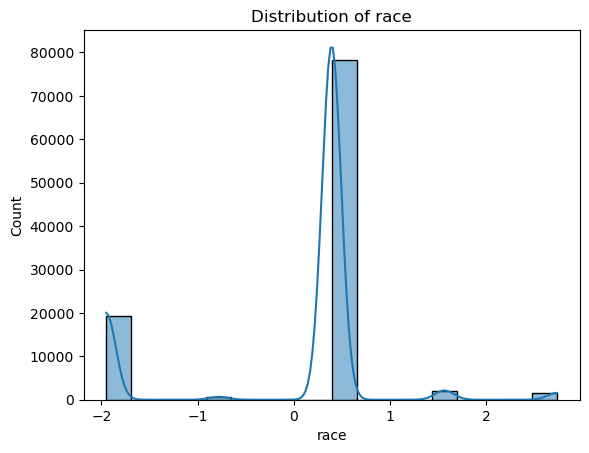

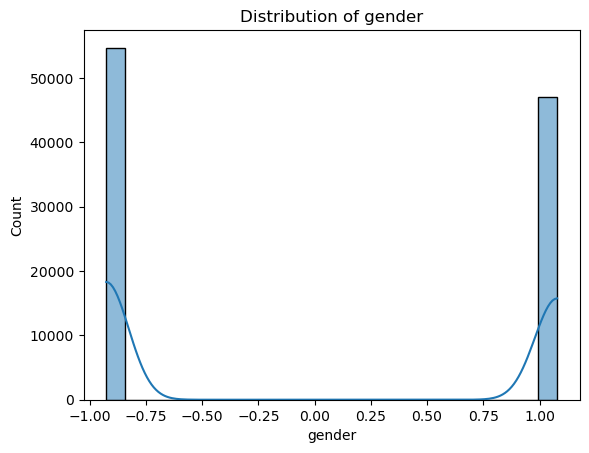

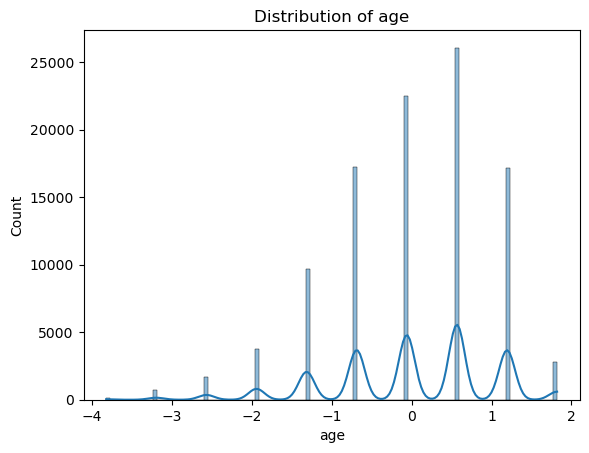

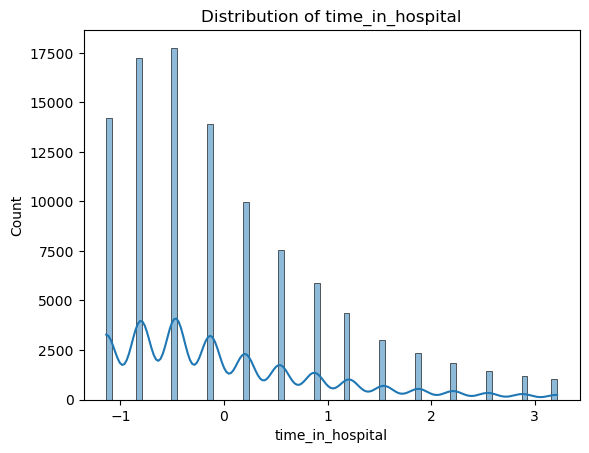

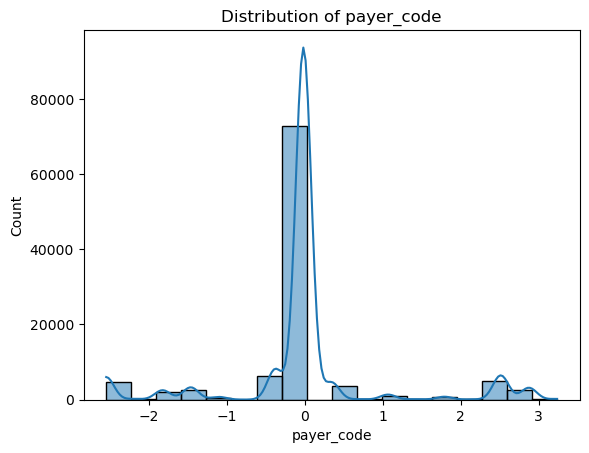

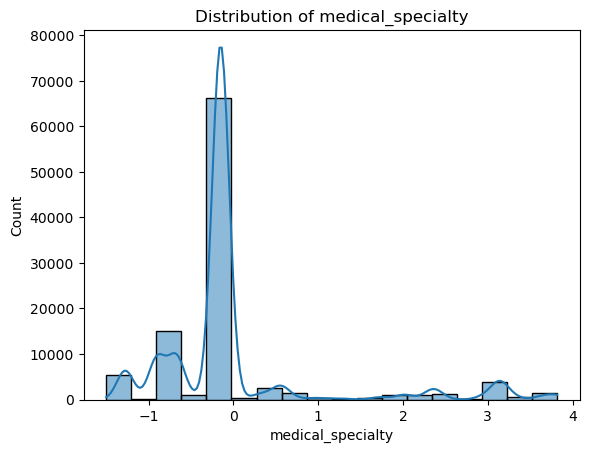

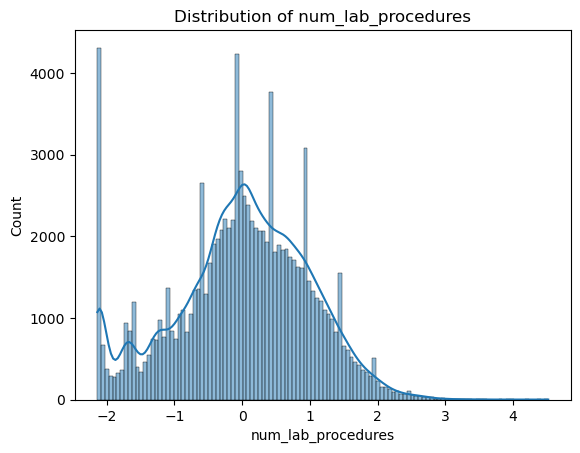

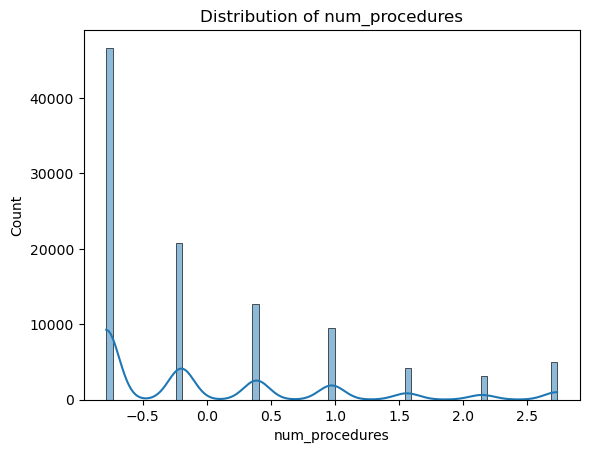

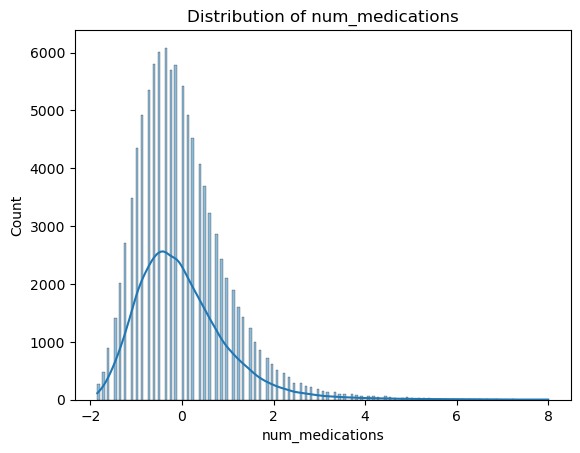

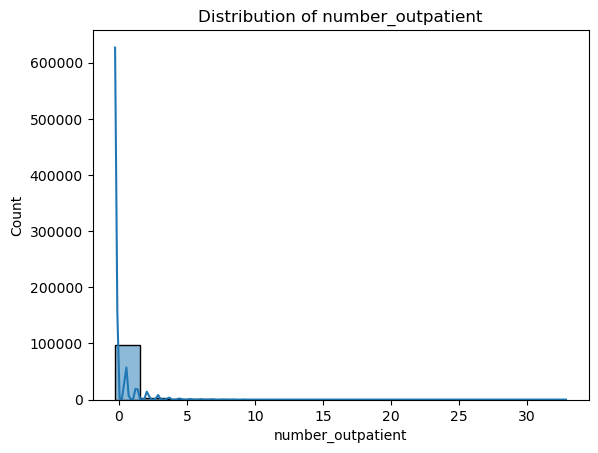

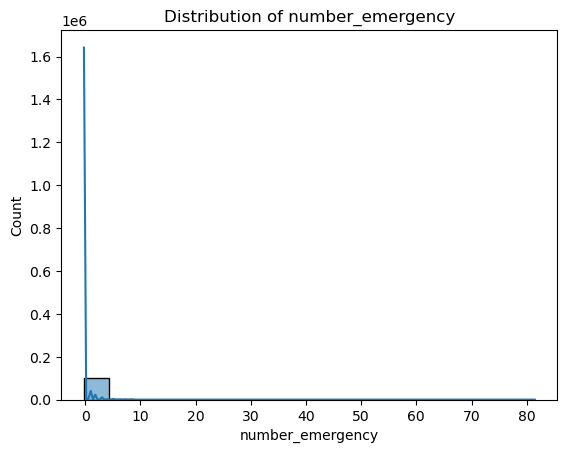

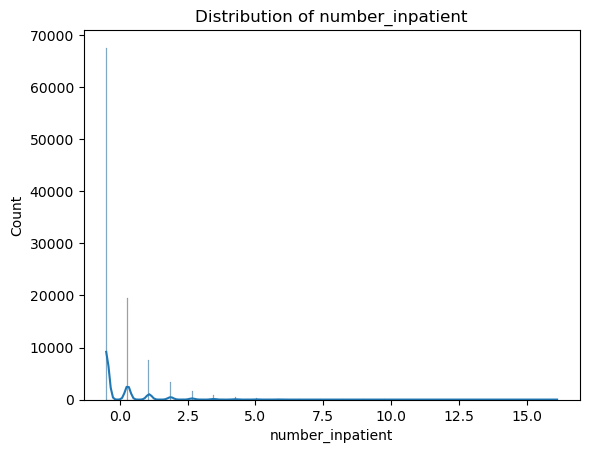

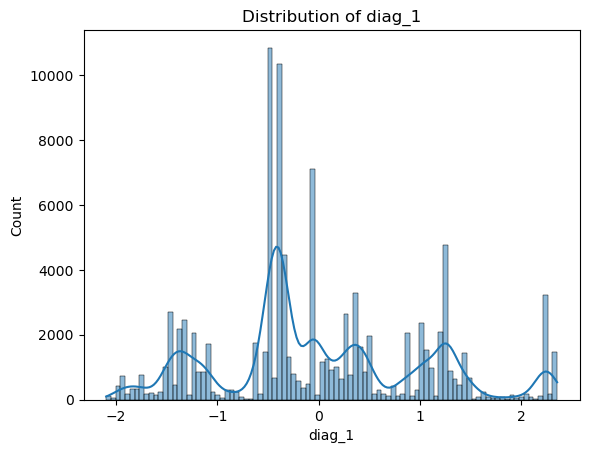

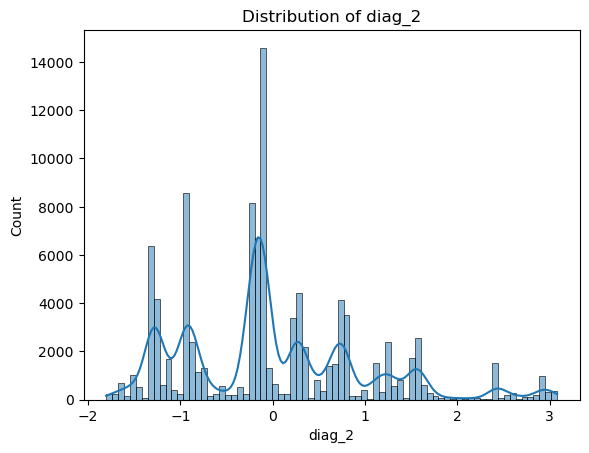

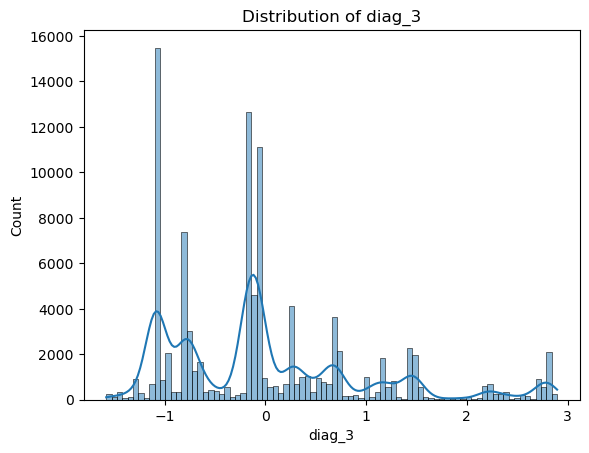

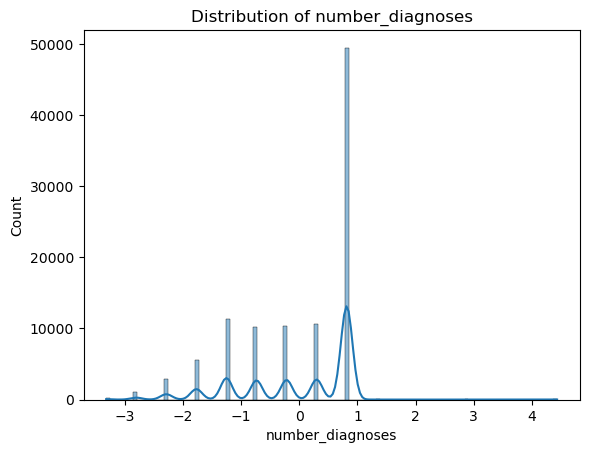

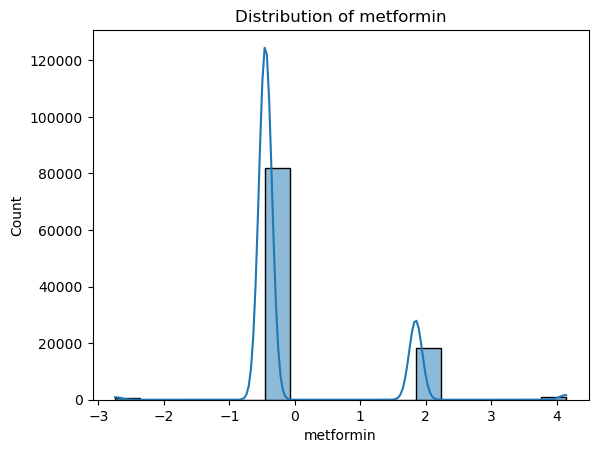

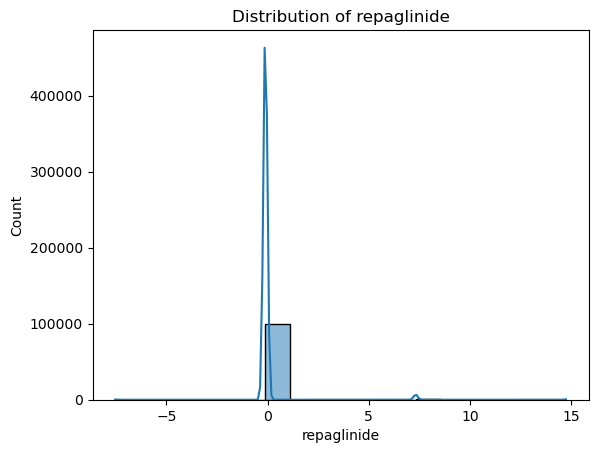

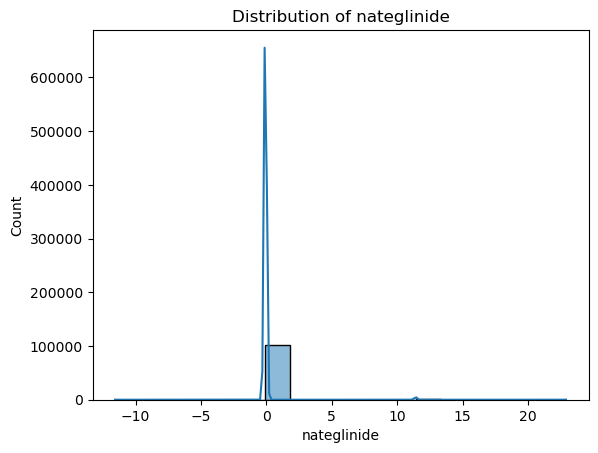

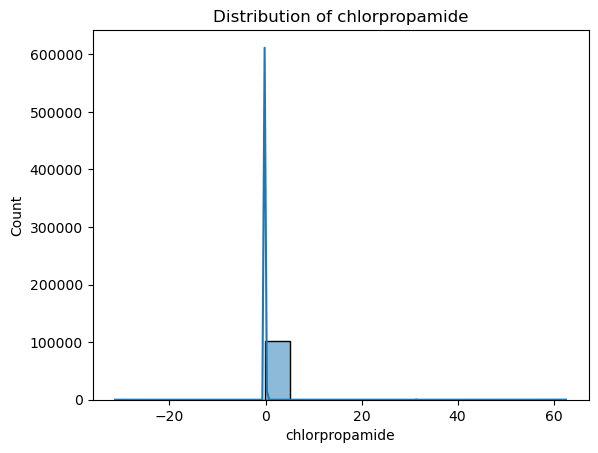

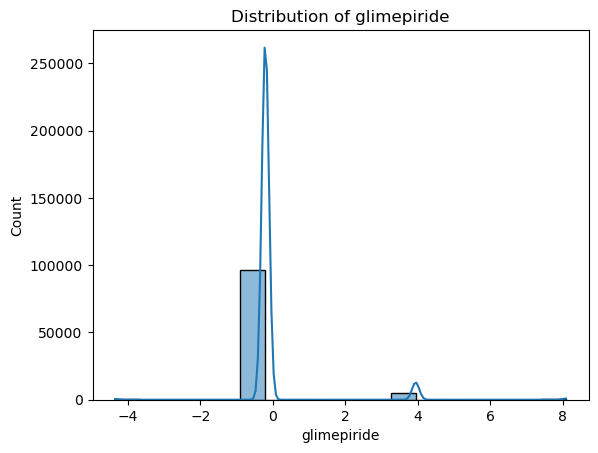

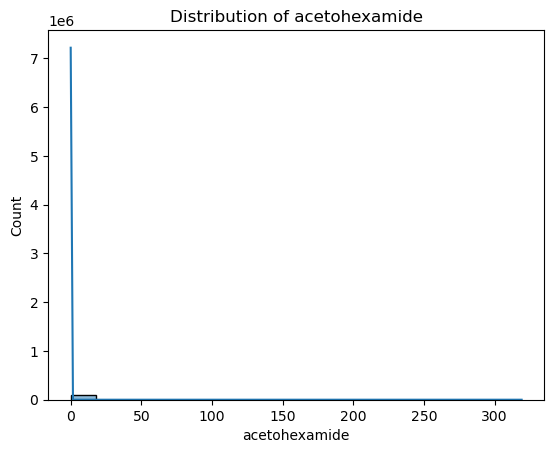

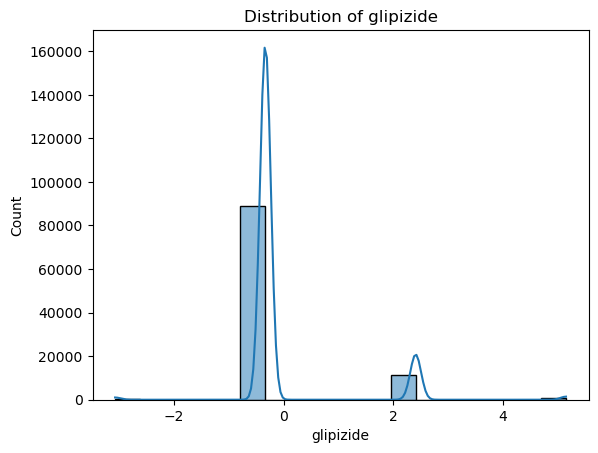

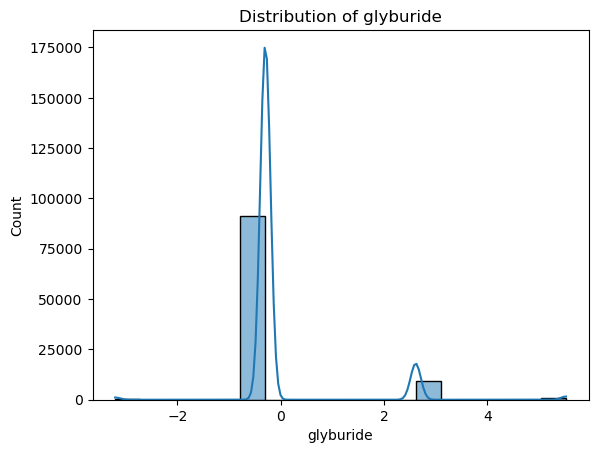

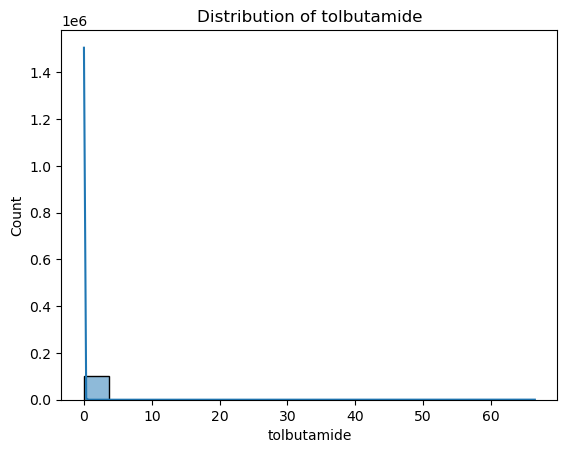

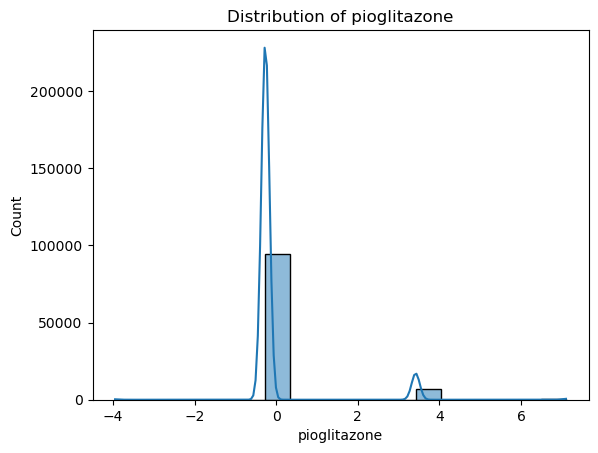

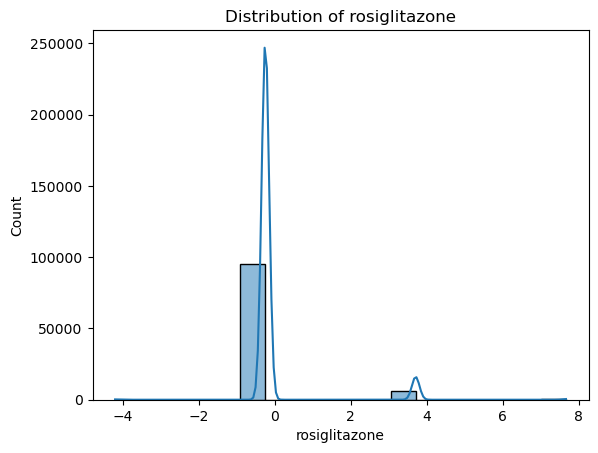

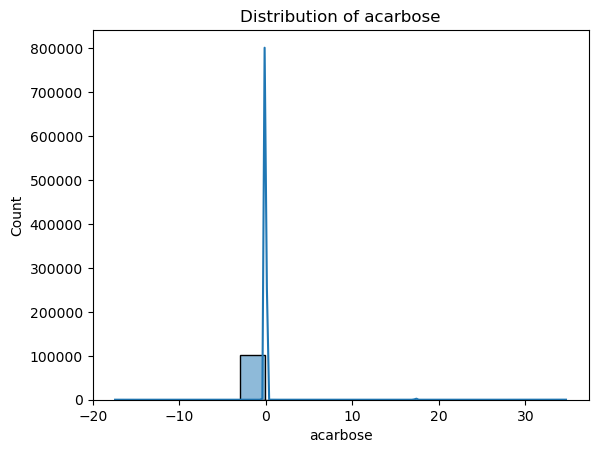

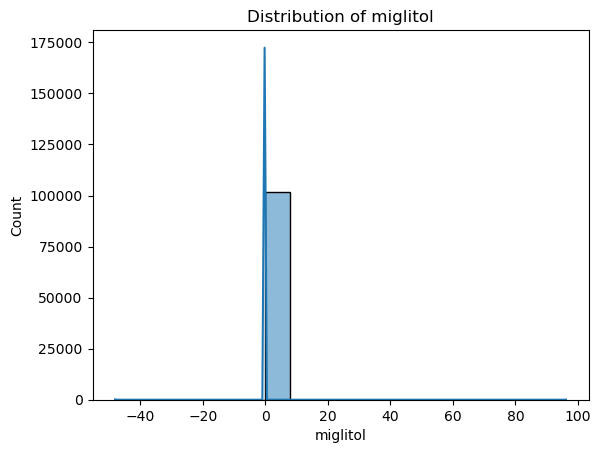

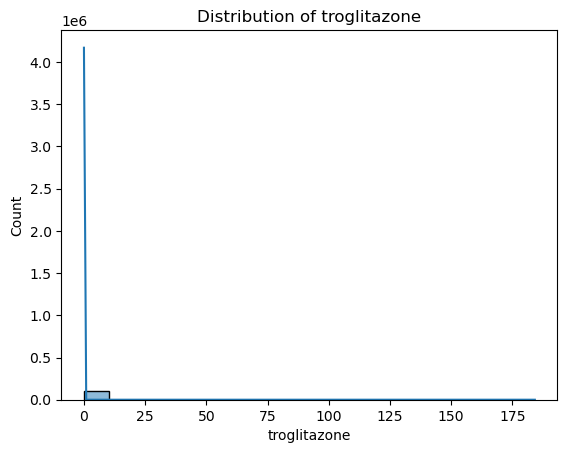

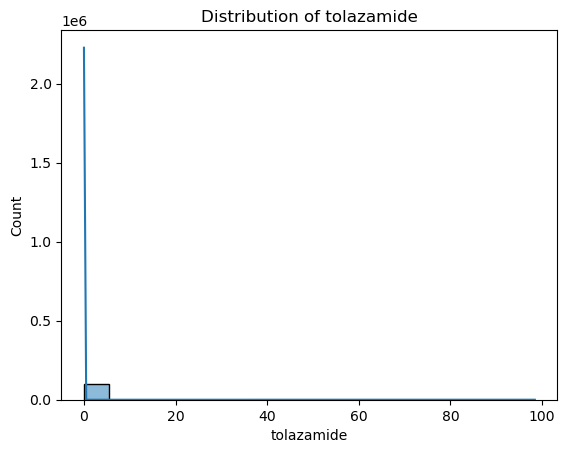

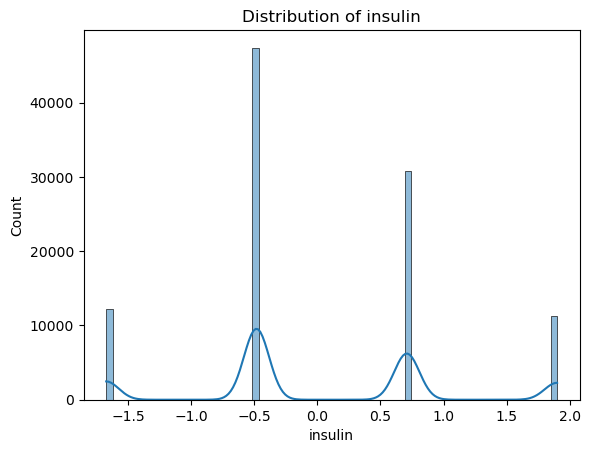

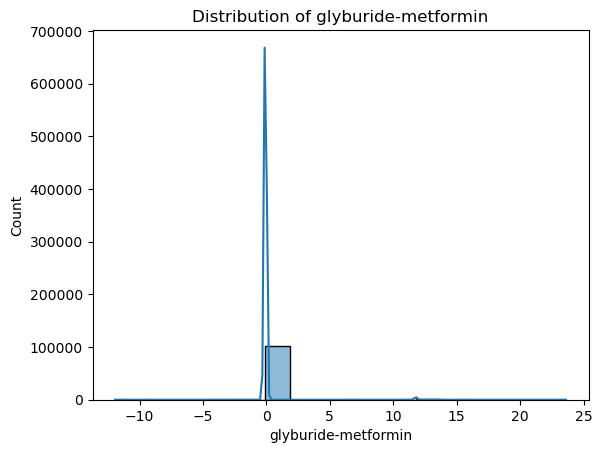

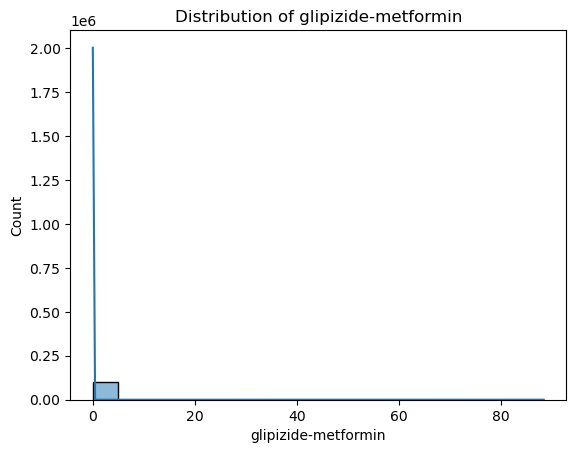

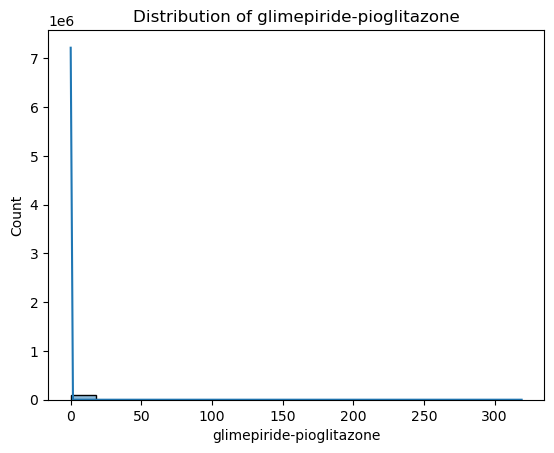

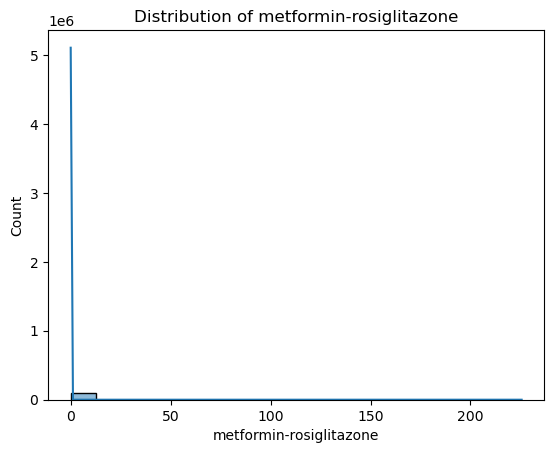

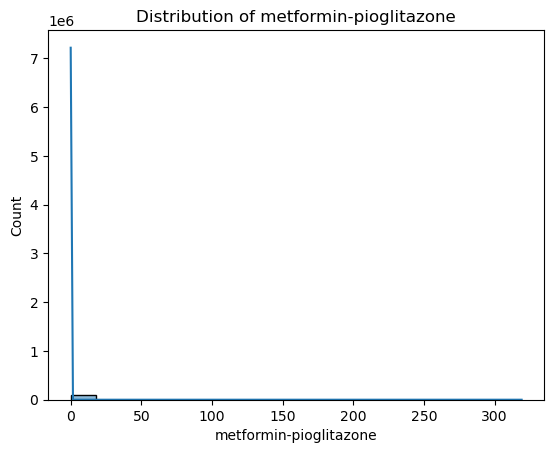

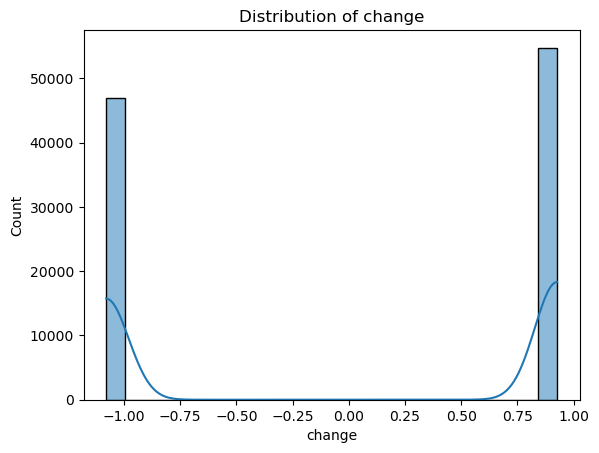

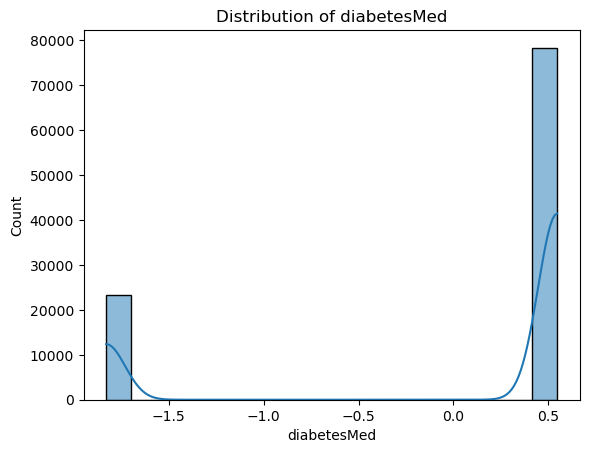

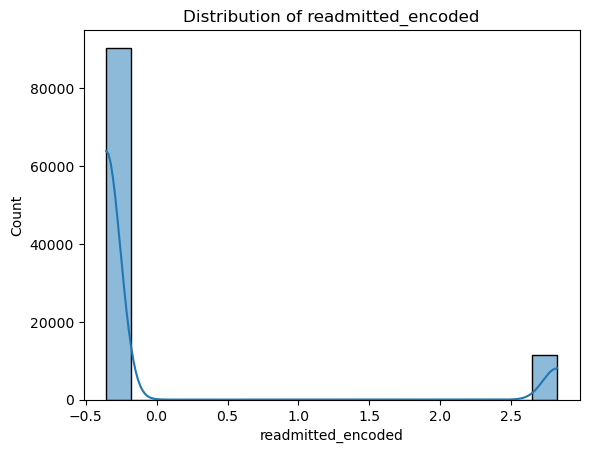

In [51]:

num_df = df.select_dtypes(include='number')
for col in num_df:
  plt.figure()
  sns.histplot(df[col], kde=True) # kde=True adds a kernel density estimate
  plt.title(f'Distribution of {col}')
plt.show()


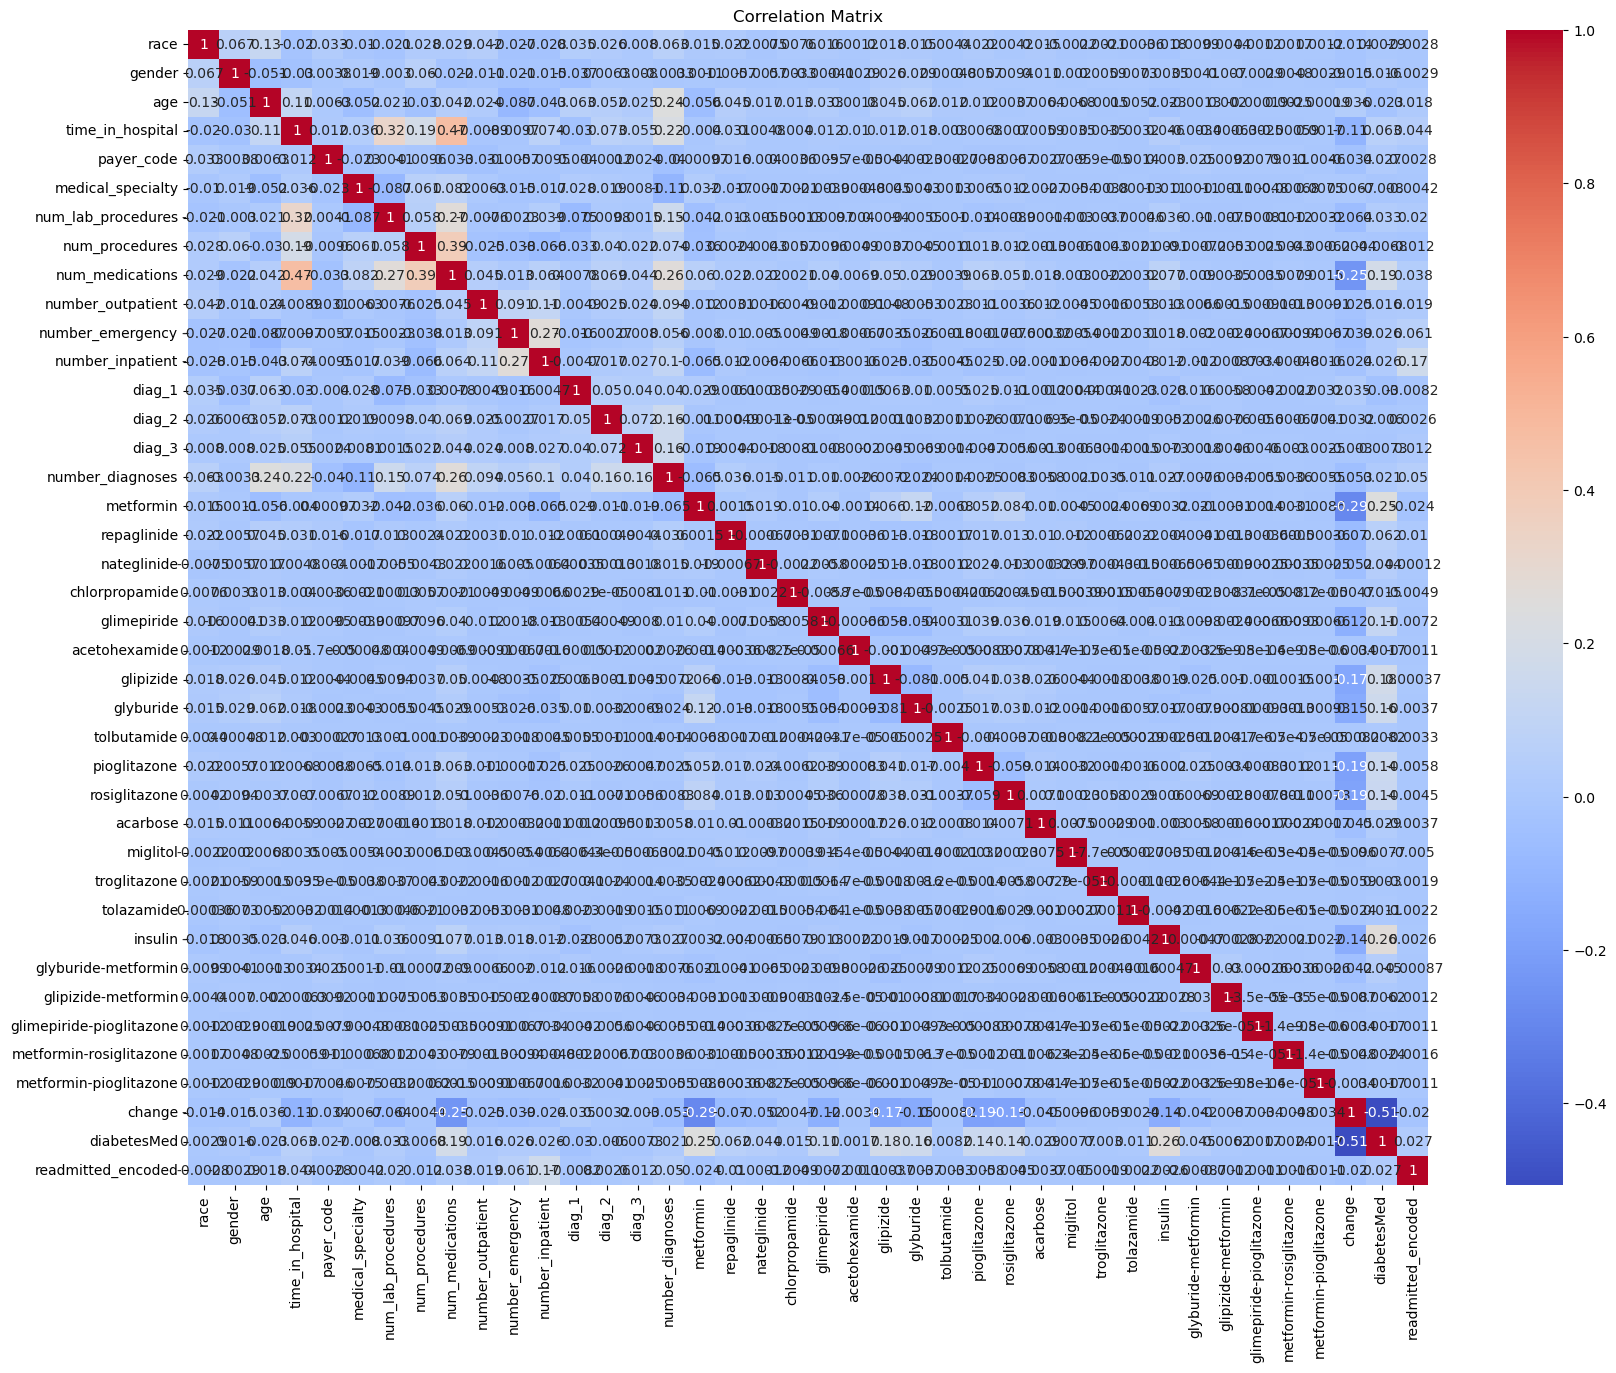

In [52]:
num_df = df.select_dtypes(include='number')

corr = num_df.corr()

plt.figure(figsize=(20, 15))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

diag_1
-0.378502    6883
-0.459484    6581
 1.266041    4016
-0.484401    3614
-0.073265    3508
-0.384732    2766
-0.048348    2275
 1.023097    2151
 0.861134    2042
-0.341126    2028
Name: count, dtype: int64


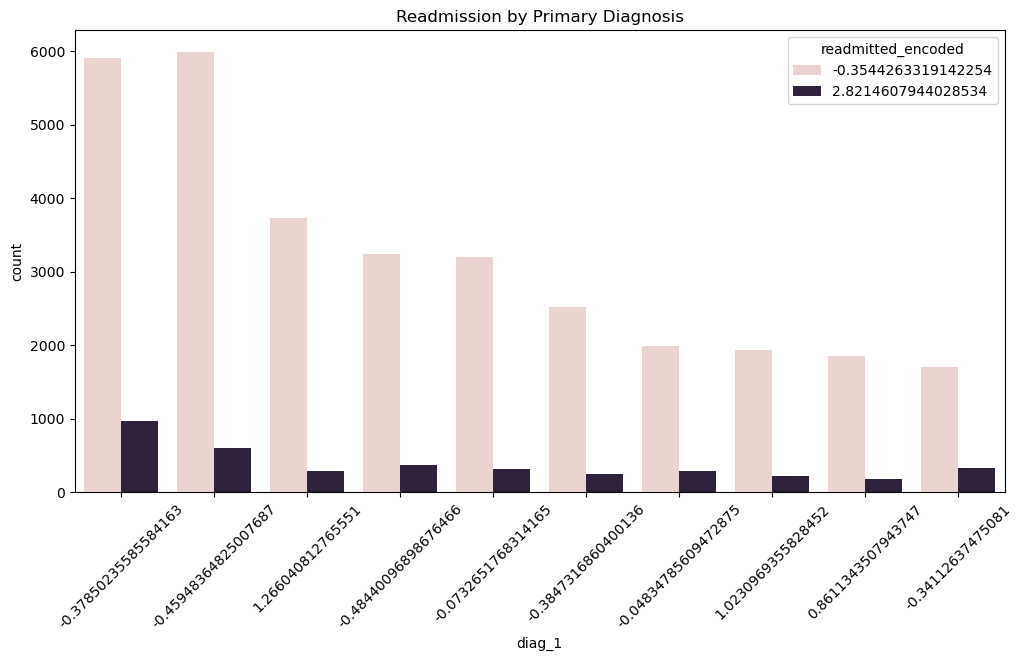

In [53]:
print(df['diag_1'].value_counts().head(10))


plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='diag_1', hue='readmitted_encoded', order=df['diag_1'].value_counts().index[:10])
plt.title('Readmission by Primary Diagnosis')
plt.xticks(rotation=45)
plt.show()

diag_2
-0.935157    7110
-0.097835    6662
-1.294945    6071
-0.104376    5036
-0.241750    3736
 0.275036    3305
 0.791821    3288
-0.228666    2823
-0.176334    2650
-0.195958    2566
Name: count, dtype: int64


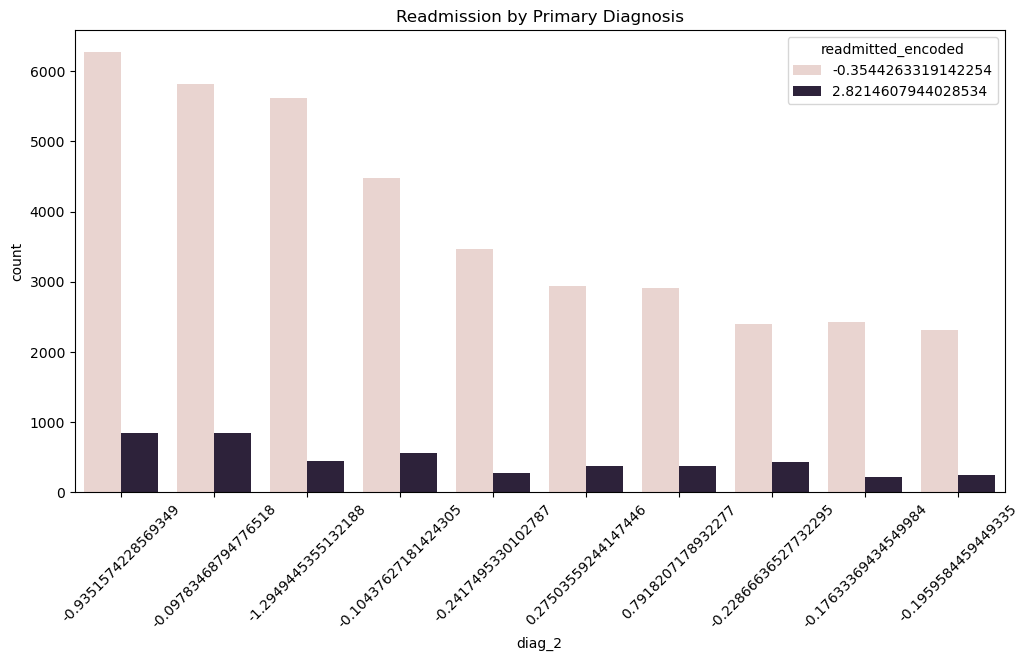

In [54]:
print(df['diag_2'].value_counts().head(10))


plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='diag_2', hue='readmitted_encoded', order=df['diag_2'].value_counts().index[:10])
plt.title('Readmission by Primary Diagnosis')
plt.xticks(rotation=45)
plt.show()

diag_3
-1.090730    12978
-0.182337     8289
-0.789825     5175
-0.057433     4577
-0.063110     3955
-0.125562     3664
 0.271860     2605
-0.170982     2357
 0.663605     1992
-0.812535     1969
Name: count, dtype: int64


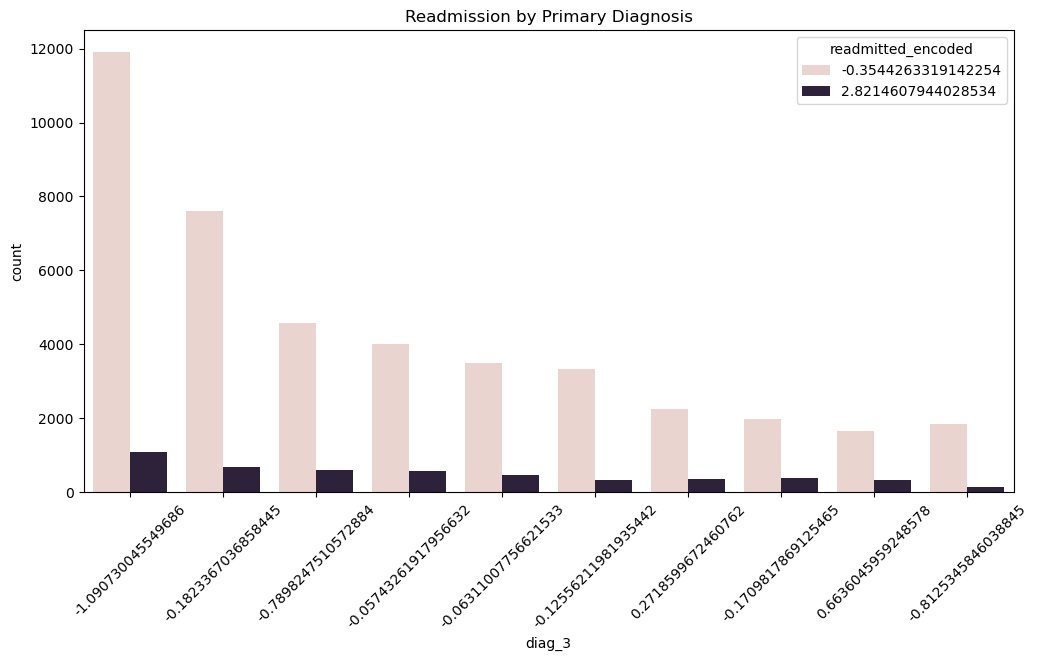

In [55]:
print(df['diag_3'].value_counts().head(10))


plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='diag_3', hue='readmitted_encoded', order=df['diag_3'].value_counts().index[:10])
plt.title('Readmission by Primary Diagnosis')
plt.xticks(rotation=45)
plt.show()

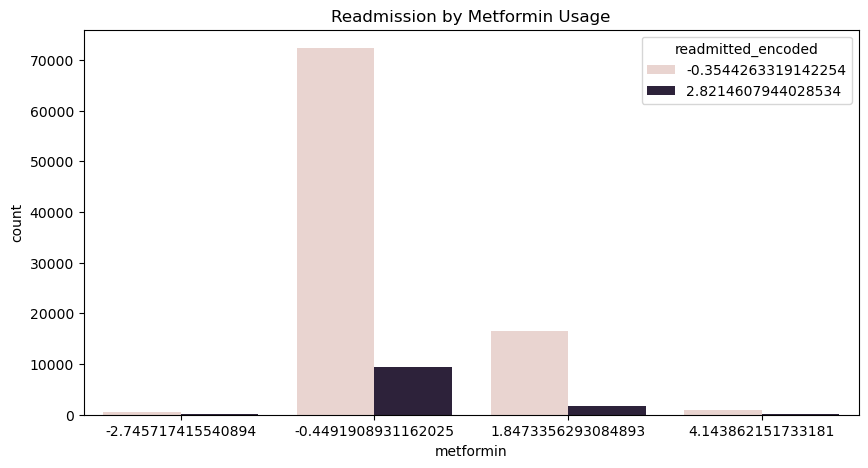

In [56]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='metformin', hue='readmitted_encoded')
plt.title('Readmission by Metformin Usage')
plt.show()

In [57]:
num_df = df.select_dtypes(include='number')
num_df = num_df.drop(['readmitted_encoded'], axis=1)
target = 'readmitted_encoded'

In [58]:
X = df[num_df.columns]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X, y = make_classification(n_samples=10000, n_features=40, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dataset created successfully with {X.shape[0]} samples and {X.shape[1]} features")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Dataset created successfully with 10000 samples and 40 features
Training set: 8000 samples
Testing set: 2000 samples


In [60]:

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")


Mean Squared Error: 0.10875824729399647
R-squared: 0.5645210804103542


Accuracy: 0.8865

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       968
           1       0.89      0.89      0.89      1032

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000

ROC-AUC Score: 0.9511820103786277


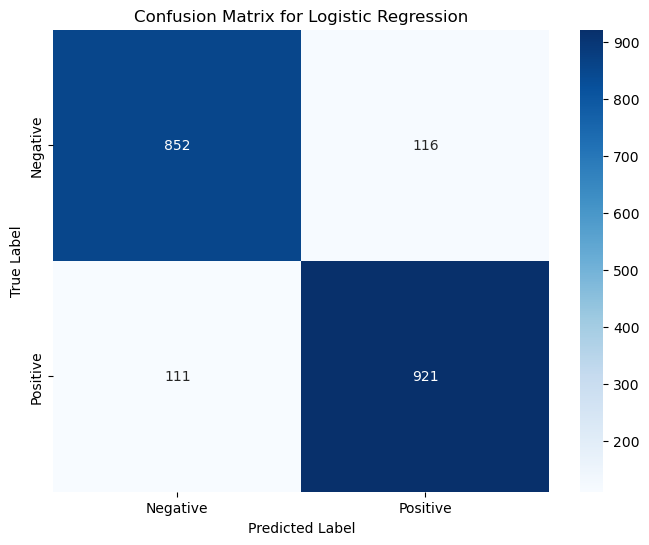

In [61]:
# Ahmed Logistic
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train, y_train)
y_pred = logreg_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
y_pred_probs = logreg_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_probs)
print("ROC-AUC Score:", roc_auc)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [65]:
# ِAbdallah
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
from sklearn.metrics import roc_auc_score

y_pred_probs = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_probs)
print("ROC-AUC Score:", roc_auc)

Accuracy: 0.9320

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       968
           1       0.92      0.95      0.94      1032

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000

ROC-AUC Score: 0.9659591421615733


In [73]:
# Abdallah SVM
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
model = SVC(kernel='rbf', probability=True)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
y_probs = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)
print("ROC-AUC Score:", roc_auc)



Accuracy: 0.9075
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.89      0.90       968
           1       0.90      0.92      0.91      1032

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000

Confusion Matrix:
 [[864 104]
 [ 81 951]]
ROC-AUC Score: 0.9534653485168813


In [ ]:
# prompt: XGboosst

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score
xgb_classifier = XGBClassifier(random_state=42, eval_metric='logloss') 
xgb_classifier.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_classifier.predict(X_test_scaled)
y_prob_xgb = xgb_classifier.predict_proba(X_test_scaled)[:, 1]
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
print("XGBoost Confusion Matrix:\n", conf_matrix_xgb)

roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print("XGBoost ROC-AUC Score:", roc_auc_xgb)


XGBoost Accuracy: 0.9315

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       968
           1       0.92      0.95      0.93      1032

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000

XGBoost Confusion Matrix:
 [[881  87]
 [ 50 982]]


NameError: name 'y_prob_xgb' is not defined

In [ ]:
# Anas Alaa ID3
from sklearn.metrics import accuracy_score, classification_report , confusion_matrix
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
conf_matrix_ID3 = confusion_matrix(y_test, y_pred)
print("Id3 Confusion Matrix:\n", conf_matrix_ID3)


Accuracy: 0.8950

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       968
           1       0.90      0.90      0.90      1032

    accuracy                           0.90      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.90      0.90      0.90      2000

Id3 Confusion Matrix:
 [[864 104]
 [106 926]]


In [ ]:
pip install pandas numpy pillow scikit-learn xgboost


In [ ]:
import tkinter as tk
from tkinter import filedialog, messagebox, ttk
from PIL import Image, ImageTk  # Make sure you have pillow installed
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

class DiabetesPredictorApp:
    def __init__(self, root):
        self.root = root
        self.root.title("Diabetes Predictor")
        
        # Load background image
        self.bg_image = Image.open("C:/Users/w.i/Downloads/Ai_Project/bg.jpg")  # Ensure this path is correct
        self.bg_image = self.bg_image.resize((600, 700), Image.Resampling.LANCZOS)
        self.bg_photo = ImageTk.PhotoImage(self.bg_image)  # Make sure this reference stays in memory

        # Create Canvas for background
        self.canvas = tk.Canvas(self.root, width=600, height=700)
        self.canvas.pack(fill="both", expand=True)
        self.canvas.create_image(0, 0, image=self.bg_photo, anchor="nw")  # Reference self.bg_photo properly

        # Variables and placeholders
        self.df = None
        self.model = None
        self.scaler = StandardScaler()
        self.encoder = LabelEncoder()
        self.feature_names = []
        self.numeric_cols = []
        self.categorical_cols = []
        self.top_features = []
        self.input_fields = []

        # UI components
        self.setup_ui()

    def setup_ui(self):
        # Upload Button
        self.upload_btn = tk.Button(self.root, text="📂 Load Dataset", command=self.load_file,
                                    font=('Arial', 12), bg='#4CAF50', fg='white')
        self.upload_window = self.canvas.create_window(300, 20, window=self.upload_btn)

        # Model Dropdown
        self.model_var = tk.StringVar(self.root)
        self.model_var.set("Logistic Regression")
        models = ["Logistic Regression", "SVM", "Random Forest", "XGBoost"]
        self.model_menu = tk.OptionMenu(self.root, self.model_var, *models)
        self.model_menu.config(font=('Arial', 12))
        self.model_window = self.canvas.create_window(300, 70, window=self.model_menu)

        # Train Button
        self.train_btn = tk.Button(self.root, text="🏋‍♂ Train Model", command=self.train_model,
                                   state=tk.DISABLED, font=('Arial', 12), bg='#2196F3', fg='white')
        self.train_window = self.canvas.create_window(300, 120, window=self.train_btn)

        # Input Fields Frame (transparent-style)
        self.inputs_frame = tk.Frame(self.root, bg='#ffffff', bd=2)
        self.inputs_label = tk.Label(self.inputs_frame, text="🔢 Enter Patient Data (Top 5 Features)",
                                     font=('Arial', 12), bg='#ffffff')
        self.inputs_label.grid(row=0, column=0, columnspan=2, pady=5)
        self.canvas.create_window(300, 250, window=self.inputs_frame)

        # Predict Button
        self.predict_btn = tk.Button(self.root, text="🔮 Predict", command=self.make_prediction,
                                     state=tk.DISABLED, font=('Arial', 12), bg='#FF9800', fg='white')
        self.canvas.create_window(300, 460, window=self.predict_btn)

        # Result Label
        self.result_label = tk.Label(self.root, text="", font=('Arial', 14, 'bold'), bg='#ffffff')
        self.result_label_window = self.canvas.create_window(300, 510, window=self.result_label)

        # Status Bar
        self.status_bar = tk.Label(self.root, text="Ready", bd=1, relief=tk.SUNKEN, anchor=tk.W, bg='white')
        self.canvas.create_window(300, 670, window=self.status_bar)


    def load_file(self):
        file_path = filedialog.askopenfilename(filetypes=[("CSV files", "*.csv")])
        if file_path:
            try:
                self.status_bar.config(text="Loading data...")
                self.root.update()
                self.df = pd.read_csv(file_path)
                self.prepare_data()
                self.select_top_features()
                self.setup_input_fields()
                self.status_bar.config(text=f"Loaded: {file_path}")
                self.result_label.config(text="✅ Data loaded successfully", fg="green")
                self.train_btn.config(state=tk.NORMAL)
            except Exception as e:
                messagebox.showerror("Error", f"Failed to load file:\n{str(e)}")
                self.status_bar.config(text="Error loading file")

    def prepare_data(self):
        self.df.replace('?', np.nan, inplace=True)
        self.df.dropna(subset=['readmitted'], inplace=True)
        self.df['target'] = self.df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
        self.numeric_cols = self.df.select_dtypes(include=['int64', 'float64']).columns.tolist()
        self.categorical_cols = self.df.select_dtypes(include=['object']).columns.tolist()
        for col in ['readmitted', 'target']:
            if col in self.numeric_cols:
                self.numeric_cols.remove(col)
            if col in self.categorical_cols:
                self.categorical_cols.remove(col)

    def select_top_features(self):
        try:
            X = self.df[self.numeric_cols + self.categorical_cols].copy()
            y = self.df['target']
            for col in self.categorical_cols:
                if col in X.columns:
                    X[col] = self.encoder.fit_transform(X[col].astype(str))
            selector = SelectKBest(score_func=f_classif, k=5)
            selector.fit(X, y)
            mask = selector.get_support()
            self.top_features = X.columns[mask].tolist()
        except Exception as e:
            messagebox.showerror("Feature Selection Error", f"Failed to select top features:\n{str(e)}")
            self.top_features = self.numeric_cols[:5]
            self.status_bar.config(text="Used fallback features")

    def setup_input_fields(self):
        for widget in self.inputs_frame.winfo_children():
            if widget != self.inputs_label:
                widget.destroy()

        self.feature_names = self.top_features[:5]
        self.input_fields = []

        for i, col in enumerate(self.feature_names):
            tk.Label(self.inputs_frame, text=f"{col}:", font=('Arial', 10), bg='#ffffff')\
                .grid(row=i+1, column=0, sticky='e')
            entry = tk.Entry(self.inputs_frame, font=('Arial', 10))
            entry.grid(row=i+1, column=1, pady=2, padx=5)
            self.input_fields.append(entry)

    def train_model(self):
        try:
            self.status_bar.config(text="Training model...")
            self.root.update()
            X = self.df[self.feature_names].copy()
            y = self.df['target']
            for col in self.categorical_cols:
                if col in X.columns:
                    X[col] = self.encoder.fit_transform(X[col].astype(str))
            numeric_cols_in_features = [col for col in self.numeric_cols if col in X.columns]
            if numeric_cols_in_features:
                X[numeric_cols_in_features] = self.scaler.fit_transform(X[numeric_cols_in_features])
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
            model_name = self.model_var.get()
            if model_name == "Logistic Regression":
                self.model = LogisticRegression(max_iter=1000)
            elif model_name == "SVM":
                self.model = SVC(probability=True)
            elif model_name == "Random Forest":
                self.model = RandomForestClassifier(n_estimators=100)
            elif model_name == "XGBoost":
                self.model = xgb.XGBClassifier()
            self.model.fit(X_train, y_train)
            accuracy = accuracy_score(y_test, self.model.predict(X_test))
            self.result_label.config(text=f"✅ Model trained\nAccuracy: {accuracy:.2%}", fg="green")
            self.predict_btn.config(state=tk.NORMAL)
            self.status_bar.config(text=f"{model_name} trained - Accuracy: {accuracy:.2%}")
        except Exception as e:
            messagebox.showerror("Training Error", f"Failed to train model:\n{str(e)}")
            self.status_bar.config(text="Training failed")

    def make_prediction(self):
        try:
            input_data = []
            for i, entry in enumerate(self.input_fields):
                value = entry.get()
                col_name = self.feature_names[i]
                if not value:
                    raise ValueError(f"Please enter value for {col_name}")
                if col_name in self.numeric_cols:
                    input_data.append(float(value))
                else:
                    input_data.append(value)
            input_df = pd.DataFrame([input_data], columns=self.feature_names)
            for col in self.categorical_cols:
                if col in input_df.columns:
                    input_df[col] = self.encoder.transform(input_df[col].astype(str))
            numeric_cols_in_features = [col for col in self.numeric_cols if col in input_df.columns]
            if numeric_cols_in_features:
                input_df[numeric_cols_in_features] = self.scaler.transform(input_df[numeric_cols_in_features])
            prediction = self.model.predict(input_df)
            proba = self.model.predict_proba(input_df)[0][1]
            result_text = f"Prediction: {'Likely' if prediction[0] == 1 else 'Not likely'} to be readmitted (Probability: {proba:.2%})"
            color = "red" if prediction[0] == 1 else "green"
            self.result_label.config(text=result_text, fg=color)
            self.status_bar.config(text="Prediction completed")
        except Exception as e:
            messagebox.showerror("Prediction Error", f"Failed to make prediction:\n{str(e)}")
            self.status_bar.config(text="Prediction failed")


if __name__ == "__main__":
    root = tk.Tk()
    app = DiabetesPredictorApp(root)
    root.geometry("600x700")
    root.mainloop()